## Curso databricks em spark Data Preparation for Machine Learning



https://customer-academy.databricks.com/learn/courses/2343/data-preparation-for-machine-learning/lessons/17953/demo-build-a-feature-engineering-pipeline-with-embeddings

In [121]:
!pip install pyspark

In [122]:


from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MeuProjetoNoColab") \
    .getOrCreate()

In [123]:
# from pyspark.sql import SparkSession

# # Inicializa a sessão Spark (Equivalente ao 'spark' que já vem pronto no Databricks)
# spark = SparkSession.builder.appName("DataCleaning").getOrCreate()

# # --- Configuração dos Caminhos ---
# # No Databricks o instrutor usa variáveis do curso (DA.paths).
# # No Colab, se você carregar o arquivo na pasta lateral, o caminho será este:
# csv_name = 'telco-customer-churn-noisy.csv'
# dataset_path = f"/content/{csv_name}"

# # --- Carregamento do Dataset ---
# # O código abaixo é exatamente o que está na sua imagem
# telco_df = spark.read.csv(
#     dataset_path,
#     header="true",
#     inferSchema="true",
#     multiLine="true",
#     escape='"'
# )

# # --- Visualização ---
# # No Colab usamos .show() ou .limit().toPandas() para ver a tabela bonitinha
# telco_df.show(5)

# # Exibe o Schema (as colunas e tipos que aparecem na parte inferior da sua imagem)
# telco_df.printSchema()

Como esse conjunto de dados está no Kaggle, a forma mais eficiente de usá-lo no Colab sem precisar baixar para no computador e fazer o upload manual é usar a API do Kaggle ou o link direto do arquivo raw (se disponível).

In [124]:
# 1. Instalar o PySpark
#!pip install pyspark -q

# 2. Importar bibliotecas e iniciar a sessão
#from pyspark.sql import SparkSession
#from pyspark.sql.functions import col
#import pandas as pd

#spark = SparkSession.builder.appName("TelcoChurn").getOrCreate()

# 3. Baixar o arquivo do Kaggle (Link direto para facilitar no Colab)
#url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
#df_pandas = pd.read_csv(url)
#df_pandas.to_csv("telco_churn.csv", index=False)

# 4. Carregar no Spark (Igual ao código da sua imagem)
#dataset_path = "telco_churn.csv"

#telco_df = spark.read.csv(
#    dataset_path,
#    header=True,
#    inferSchema=True,
#    multiLine=True,
#    escape='"'
#)

# 5. Visualizar o resultado (Equivalente ao display() do Databricks)
#telco_df.limit(5).toPandas()

In [125]:
# 1. Instalar o PySpark
#!pip install pyspark -q

# 2. Importar bibliotecas e iniciar a sessão
#from pyspark.sql import SparkSession
#from pyspark.sql.functions import col, regexp_replace
#import pandas as pd

#spark = SparkSession.builder.appName("TelcoChurn").getOrCreate()

# --- NOVIDADE AQUI: Desativa o modo rígido para evitar o erro de CAST ---
#spark.conf.set("spark.sql.ansi.enabled", "false")

# 3. Baixar o arquivo
#url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
#df_pandas = pd.read_csv(url)
#df_pandas.to_csv("telco_churn.csv", index=False)

# 4. Carregar no Spark com LIMPEZA IMEDIATA
#dataset_path = "telco_churn.csv"

# Carregamos primeiro como texto para não dar erro no inferSchema
#telco_df_raw = spark.read.csv(
#    dataset_path,
#    header=True,
#    inferSchema=True,
#    multiLine=True,
#    escape='"'
#)

# --- NOVIDADE AQUI: Limpa os espaços vazios das colunas problemáticas ---
# O regexp_replace vai trocar qualquer espaço (" ") por nada,
# e o .cast("double") vai transformar isso em um NULL amigável.
#telco_df = telco_df_raw.withColumn(
#    "TotalCharges",
#    regexp_replace(col("TotalCharges"), "^\s*$", None).cast("double")
#).withColumn(
#    "MonthlyCharges",
#    regexp_replace(col("MonthlyCharges"), "^\s*$", None).cast("double")
#)

# 5. Visualizar o resultado
#telco_df.limit(5).toPandas()

In [126]:
# 1. Instalar o PySpark
!pip install pyspark -q

# 2. Importar bibliotecas e iniciar a sessão
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, when, trim
import pandas as pd

spark = SparkSession.builder.appName("TelcoChurn").getOrCreate()

# Desativa o modo ANSI para evitar erros fatais de conversão
spark.conf.set("spark.sql.ansi.enabled", "false")

# 3. Baixar o arquivo
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df_pandas = pd.read_csv(url)
df_pandas.to_csv("telco_churn.csv", index=False)

# 4. Carregar no Spark SEM inferSchema (para evitar que ele quebre as colunas antes da hora)
dataset_path = "telco_churn.csv"

telco_df_raw = spark.read.csv(
    dataset_path,
    header=True,
    inferSchema=False, # Mudamos para False aqui
    multiLine=True,
    escape='"'
)

# 5. LIMPEZA E CONVERSÃO
# Usamos o trim() para tirar espaços e o cast direto.
# Com o ansi.enabled=false, o que não for número vira NULL automaticamente.
telco_df = telco_df_raw.withColumn(
    "TotalCharges",
    col("TotalCharges").cast("double")
).withColumn(
    "MonthlyCharges",
    col("MonthlyCharges").cast("double")
)

# 6. Visualizar o resultado
# Agora as colunas devem aparecer com os valores decimais corretamente.
display(telco_df.limit(5).toPandas())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [127]:
telco_df.toPandas()['MonthlyCharges'].unique()

array([29.85, 56.95, 53.85, ..., 63.1 , 44.2 , 78.7 ])

In [128]:
from pyspark.sql.types import DoubleType
telco_df = telco_df.withColumn("TotalCharges", col("TotalCharges").cast(DoubleType()))

In [129]:
telco_df.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: string (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: string (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)



# Corrigindo Tipos de Dados (Coerce / Fix Data Types)
Esta etapa é fundamental para converter colunas que o Spark leu como texto ou número, mas que logicamente são valores Booleanos (Verdadeiro/Falso).

In [130]:
# Importação dos tipos necessários do Spark SQL
from pyspark.sql.types import BooleanType, ShortType, IntegerType
from pyspark.sql.functions import col, when

# --- PARTE 1: Converter SeniorCitizen e Churn para BooleanType ---

# Criamos uma lista com as colunas binárias que queremos transformar
binary_columns = ["SeniorCitizen", "Churn"]

# Criamos um novo DataFrame (ou atualizamos o atual) aplicando a transformação
telco_customer_churn_df = telco_df

# Loop para percorrer cada coluna da nossa lista e mudar o tipo para Booleano
for column in binary_columns:
    # .withColumn substitui a coluna existente pela versão convertida (.cast)
    telco_customer_churn_df = telco_customer_churn_df.withColumn(
        column,
        col(column).cast(BooleanType())
    )

# Exibe o esquema apenas dessas colunas para conferir se agora são 'boolean'
telco_customer_churn_df.select(*binary_columns).printSchema()


root
 |-- SeniorCitizen: boolean (nullable = true)
 |-- Churn: boolean (nullable = true)



# Conversão de múltiplas colunas para Booleano via Spark SQL
Nesta célula, o instrutor utiliza uma sintaxe SQL mais elegante para converter várias colunas de uma só vez, mantendo as restantes.

In [131]:
# --- EXPLICAÇÃO ---
# Primeiro, as colunas PhoneService, PaperlessBilling, Partner e Dependents
# são convertidas para o tipo BOOLEAN usando a função BOOLEAN() do Spark SQL.
# O uso do 'EXCEPT' é um recurso moderno do Spark SQL que permite selecionar
# todas as colunas (*) exceto as que estamos transformando manualmente,
# evitando duplicidade de colunas no resultado final.

telco_customer_churn_df.createOrReplaceTempView("telco_customer_churn_temp_view")

telco_customer_casted_df = spark.sql("""
    SELECT
        customerID,
        BOOLEAN(Dependents),
        BOOLEAN(Partner),
        BOOLEAN(PhoneService),
        BOOLEAN(PaperlessBilling),
        * EXCEPT (customerID, Dependents, Partner, PhoneService, PaperlessBilling, Churn),
        Churn
    FROM telco_customer_churn_temp_view
""")

# Verifica se os tipos foram alterados corretamente para 'boolean'
telco_customer_casted_df.select("Dependents", "Partner", "PaperlessBilling", "PhoneService").printSchema()

root
 |-- Dependents: boolean (nullable = true)
 |-- Partner: boolean (nullable = true)
 |-- PaperlessBilling: boolean (nullable = true)
 |-- PhoneService: boolean (nullable = true)



# Conversão da coluna 'Tenure' usando .selectExpr
Aqui o instrutor mostra uma terceira forma de transformar dados: o método selectExpr, que aceita strings de SQL diretamente no DataFrame API.

In [132]:
# --- EXPLICAÇÃO ---
# A coluna 'tenure' (tempo de contrato) geralmente é lida como número inteiro simples.
# Aqui ela é convertida para 'Long' (um inteiro de 64 bits, que suporta números maiores).
# O padrão "* except(tenure)" diz ao Spark: "pegue todas as colunas, menos a tenure original",
# e o "cast(tenure as long) tenure" diz: "adicione a tenure convertida com o mesmo nome".

telco_customer_casted_df = telco_customer_casted_df.selectExpr(
    "* except(tenure)",
    "cast(tenure as long) tenure"
)

# Confirma que a coluna tenure agora é do tipo 'long'
telco_customer_casted_df.select("tenure").printSchema()

root
 |-- tenure: long (nullable = true)



# Handle Invalid Values and Review Distributions
Outliers (valores atípicos) podem distorcer o treinamento do modelo e os resumos estatísticos. Nós os abordamos em duas etapas:

Remover linhas com TotalCharges negativos — estes são claramente valores errôneos, pois cobranças não podem ser negativas.

Revisar a distribuição de PaymentMethod — entender como os clientes estão distribuídos entre os tipos de pagamento ajuda a informar decisões de codificação (encoding) posteriormente.

Filtering out negative TotalCharges
Valores negativos em TotalCharges são problemas de qualidade de dados. Removemos essas linhas enquanto preservamos as linhas onde TotalCharges é nulo (que serão tratadas separadamente na etapa de imputação).

In [133]:
# Importação da função col para manipulação de colunas
from pyspark.sql.functions import col

# --- EXPLICAÇÃO ---
# Definimos um ponto de corte (cutoff) igual a 0.
# No filtro, usamos uma lógica de 'OU' (representada pelo símbolo |).
# Queremos manter a linha se:
# 1. O valor de TotalCharges for maior ou igual a 0.
# 2. OU se o valor for nulo (isNull), pois nulos serão tratados em outra etapa.
# Isso remove automaticamente os valores negativos (ex: -500).

TotalCharges_cutoff = 0

telco_no_outliers_df = telco_customer_casted_df.filter(
    (col("TotalCharges") >= TotalCharges_cutoff) |
    (col("TotalCharges").isNull())  # Mantém nulos para a etapa de imputação
)

# O resultado é um novo DataFrame chamado 'telco_no_outliers_df'

# Exploring Payment Method Distribution
Let's review how customers are distributed across PaymentMethod categories. This is a useful step before encoding — it helps identify whether any categories are rare enough to require special handling.

Note: In this dataset, all PaymentMethod categories are well-represented. We do not remove any rows based on frequency here. In a real-world scenario with a high-cardinality feature containing very rare categories, you might consider grouping them under a common label such as "Other" before encoding.

In [134]:
telco_no_outliers_df.show(5)

+----------+----------+-------+------------+----------------+------+-------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+--------------------+--------------+------------+-----+------+
|customerID|Dependents|Partner|PhoneService|PaperlessBilling|gender|SeniorCitizen|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|tenure|
+----------+----------+-------+------------+----------------+------+-------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+--------------------+--------------+------------+-----+------+
|7590-VHVEG|     false|   true|       false|            true|Female|        false|No phone service|            DSL|            No|         Yes|              No|      

In [135]:
spark.conf.set("spark.sql.ansi.enabled", "false")
#Se quiser que o Spark seja "bonzinho" e apenas coloque null automaticamente sempre que um cast falhar (sem travar o código), você pode rodar este comando no topo do seu notebook:

In [136]:
from pyspark.sql.functions import col, count, avg, expr

# --- EXPLICAÇÃO ---
# 1. Usamos expr("CAST(MonthlyCharges AS DOUBLE)") para garantir que
#    o Spark trate a coluna como número na hora do cálculo.
# 2. Com o modo ANSI desativado (Passo 1), o Spark não vai mais travar.

group_var = "PaymentMethod"

stats_df = telco_no_outliers_df.groupBy(group_var) \
    .agg(
        count("*").alias("Total"),
        avg(col("MonthlyCharges").cast("double")).alias("MonthlyCharges")
    ) \
    .orderBy(col("Total").desc())

# Agora o .show() deve funcionar perfeitamente
stats_df.show()

+--------------------+-----+------------------+
|       PaymentMethod|Total|    MonthlyCharges|
+--------------------+-----+------------------+
|    Electronic check| 2365| 76.25581395348838|
|        Mailed check| 1612|43.917059553349915|
|Bank transfer (au...| 1544|  67.1926489637305|
|Credit card (auto...| 1522| 66.51238501971082|
+--------------------+-----+------------------+



In [137]:
stats_df.filter(col("MonthlyCharges").isNotNull()).show()

+--------------------+-----+------------------+
|       PaymentMethod|Total|    MonthlyCharges|
+--------------------+-----+------------------+
|    Electronic check| 2365| 76.25581395348838|
|        Mailed check| 1612|43.917059553349915|
|Bank transfer (au...| 1544|  67.1926489637305|
|Credit card (auto...| 1522| 66.51238501971082|
+--------------------+-----+------------------+



In [138]:
# Importação das funções necessárias para agregação
from pyspark.sql.functions import col, count, avg

# --- EXPLICAÇÃO ---
# 1. Definimos a variável de agrupamento (PaymentMethod).
# 2. Usamos .groupBy() para reunir os dados por essa categoria.
# 3. .agg() realiza as operações matemáticas:
#    - count("*") conta quantos clientes existem em cada grupo (Total).
#    - avg("MonthlyCharges") calcula a média de cobrança mensal por grupo.
# 4. .orderBy() organiza o resultado do maior para o menor total (.desc()).

#group_var = "PaymentMethod"

#stats_df = telco_no_outliers_df.groupBy(group_var) \
#    .agg(
#        count("*").alias("Total"),
#        avg("MonthlyCharges").alias("MonthlyCharges")
#    ) \
#    .orderBy(col("Total").desc())

# No Databricks usa-se display(), no Colab usamos .show() ou convertemos para Pandas
# display(stats_df)
#stats_df.show()

## Salvando os Dados (Camada Silver)

In [139]:
# --- EXPLICAÇÃO ---
# Na arquitetura Medalhão (Lakehouse), a tabela "Silver" é aquela que
# já passou por limpeza inicial e correção de tipos.
# O comando .write.mode("overwrite") garante que, se você rodar a célula
# novamente, ele substituirá o arquivo antigo pelo novo.

telco_customer_name_full = "telco_customer_full"
file_path_silver = f"{telco_customer_name_full}_silver"

# Comando adaptado para o Colab (Salvando como Parquet, que é mais eficiente que CSV)
telco_no_outliers_df.write.mode("overwrite").parquet(file_path_silver)

print(f"Dataset salvo com sucesso em: {file_path_silver}")

Dataset salvo com sucesso em: telco_customer_full_silver


# 2. Identificando Valores Ausentes (Imagens ff03fa, ff03bc e feb239)
As suas novas imagens mostram a criação de uma função auxiliar robusta para contar nulos, strings vazias e até palavras como "none" ou "null" que podem estar escondidas no dataset.

In [142]:
from pyspark.sql.functions import col, when, count, trim, lower
from pyspark.sql.functions import concat_ws, collect_list, sum, length
from pyspark.sql.functions import col, collect_list, concat_ws

def calculate_missing(input_df, show=True):
    """
    Função baseada na Célula 22 das imagens enviadas.
    Calcula nulos, strings vazias e termos 'null'/'none'.
    """
    # Agregação para contar valores ausentes por coluna
    missing_df_ = input_df.agg(*[
        sum(when(
            col(c).isNull() |
            (length(trim(col(c).cast("string"))) == 0) |
            (lower(trim(col(c).cast("string"))).isin(["none", "null"])),
            1,
        ).otherwise(0)
        ).alias(c)
        for c in input_df.columns
    ])




    def TransposeDF(df, columns, pivotCol):
        """
        Função auxiliar para transpor um Spark DataFrame de uma linha larga
        em múltiplas linhas verticais (formato longo).
        """
        # 1. Cria uma lista de strings formatadas para a função stack do SQL
        # Cada entrada será algo como: "'NomeDaColuna', NomeDaColuna"
        columnsValue = list(
            map(lambda x: str("'") + str(x) + str("',") + str(x), columns)
        )

        # 2. Une todas as strings com vírgulas
        stackCols = ",".join(x for x in columnsValue)

        # 3. Usa selectExpr com a função STACK do Spark SQL
        # O número str(len(columns)) indica quantas linhas serão criadas na transposição
        df_1 = df.selectExpr(
            pivotCol,
            f"stack({str(len(columns))}, {stackCols})"
        ).select(pivotCol, col("col0"), col("col1"))

        # 4. Agrupa e organiza o resultado final
        final_df = (
            df_1.groupBy(col("col0"))
            .pivot(pivotCol)
            .agg(concat_ws("", collect_list(col("col1"))))
            .withColumnRenamed("col0", pivotCol)
        )

        return final_df

        # 2. Criamos o DataFrame transposto
        # 'missing_df' é o resultado do .agg() com as contagens de nulos
        # spark.createDataFrame([...]) cria a coluna que servirá de rótulo para os valores
    missing_df_out_T = TransposeDF(
            spark.createDataFrame([{"Column": "Number of Missing Values"}]).join(missing_df_),
            missing_df_.columns,
            "Column"
        ).withColumn(
            "Number of Missing Values",
            col("Number of Missing Values").cast("long")
        )

    if show:
          # 4. Exibimos o resultado ordenado do maior para o menor
          # No Colab, usamos .show() ou convertemos para Pandas para uma tabela bonita
          display(missing_df_out_T.orderBy("Number of Missing Values", ascending=False))

    return missing_df_out_T





In [143]:
telco_no_outliers_df.show()

+----------+----------+-------+------------+----------------+------+-------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+--------------------+--------------+------------+-----+------+
|customerID|Dependents|Partner|PhoneService|PaperlessBilling|gender|SeniorCitizen|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    StreamingMovies|      Contract|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|tenure|
+----------+----------+-------+------------+----------------+------+-------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+--------------------+--------------+------------+-----+------+
|7590-VHVEG|     false|   true|       false|            true|

In [144]:
from pyspark.sql.functions import col, when, count, trim, lower, concat_ws, collect_list, sum, length, lit

# 1. Mantenha a TransposeDF fora para evitar conflitos de escopo
def TransposeDF(df, columns, pivotCol):
    """
    Função auxiliar para transpor um Spark DataFrame de uma linha larga
    em múltiplas linhas verticais (formato longo).
    """
    # Cria uma lista de strings formatadas para a função stack do SQL
    columnsValue = list(
        map(lambda x: str("'") + str(x) + str("',") + str(x), columns)
    )

    stackCols = ",".join(x for x in columnsValue)

    # Usa a função STACK do Spark SQL para girar as colunas
    df_1 = df.selectExpr(
        pivotCol,
        f"stack({str(len(columns))}, {stackCols})"
    ).select(pivotCol, col("col0"), col("col1"))

    # Agrupa e organiza o resultado final
    final_df = (
        df_1.groupBy(col("col0"))
        .pivot(pivotCol)
        .agg(concat_ws("", collect_list(col("col1"))))
        .withColumnRenamed("col0", pivotCol)
    )

    return final_df

# 2. Agora a calculate_missing chama a função acima
def calculate_missing(input_df, show=True):
    """
    Identifica colunas com valores nulos, vazios ou termos como 'null'/'none'.
    """
    # Agregação para contar valores ausentes por coluna
    missing_df_ = input_df.agg(*[
        sum(when(
            col(c).isNull() |
            (length(trim(col(c).cast("string"))) == 0) |
            (lower(trim(col(c).cast("string"))).isin(["none", "null"])),
            1,
        ).otherwise(0)).alias(c)
        for c in input_df.columns
    ])

    # Prepara o DataFrame para transposição
    # Usamos lit() para criar a coluna de rótulo corretamente
    pivot_label = "Number of Missing Values"
    missing_df_with_label = missing_df_.withColumn("Column", lit(pivot_label))

    # Chama a função de transposição
    missing_df_out_T = TransposeDF(
        missing_df_with_label,
        input_df.columns,
        "Column"
    ).withColumn(
        pivot_label,
        col(pivot_label).cast("long")
    )

    if show:
        # Exibe ordenado do maior para o menor
        display(missing_df_out_T.orderBy(pivot_label, ascending=False))

    return missing_df_out_T

# 3. Execução
missing_df = calculate_missing(telco_no_outliers_df)

DataFrame[Column: string, Number of Missing Values: bigint]

In [146]:
display(missing_df.orderBy("Number of Missing Values", ascending=False))

DataFrame[Column: string, Number of Missing Values: bigint]

In [147]:
# O .toPandas() transforma o resultado em uma tabela visual bonita no Colab
display(missing_df.orderBy("Number of Missing Values", ascending=False).toPandas())

,Column,Number of Missing Values
0,TotalCharges,11
1,customerID,0
2,Dependents,0
3,Partner,0
4,PhoneService,0
5,PaperlessBilling,0
6,gender,0
7,SeniorCitizen,0
8,MultipleLines,0
9,InternetService,0


In [148]:
telco_df.toPandas().isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# 5. Drop de Colunas com mais de 60% de Nulos

In [149]:
# Drop columns with more than 60% missing data
# Colunas com excesso de valores ausentes introduzem ruído. Nós as identificamos e removemos.

per_thresh = 0.6 # Limite de 60% para remoção
N = telco_no_outliers_df.count()

# Identificando colunas para remover
to_drop_missing = [x.asDict()['Column'] for x in missing_df.select("Column")
                   .where(col("Number of Missing Values") / N >= per_thresh).collect()]

print(f"Dropping columns {to_drop_missing} for more than {per_thresh * 100}% missing data")

# Criando o DataFrame final sem as colunas ruidosas
telco_no_missing_df = telco_no_outliers_df.drop(*to_drop_missing)
display(telco_no_missing_df)

Dropping columns [] for more than 60.0% missing data


DataFrame[customerID: string, Dependents: boolean, Partner: boolean, PhoneService: boolean, PaperlessBilling: boolean, gender: string, SeniorCitizen: boolean, MultipleLines: string, InternetService: string, OnlineSecurity: string, OnlineBackup: string, DeviceProtection: string, TechSupport: string, StreamingTV: string, StreamingMovies: string, Contract: string, PaymentMethod: string, MonthlyCharges: double, TotalCharges: double, Churn: boolean, tenure: bigint]

In [150]:
display(telco_no_missing_df.count())

7043

In [151]:
display(telco_no_missing_df.show())

+----------+----------+-------+------------+----------------+------+-------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+--------------------+--------------+------------+-----+------+
|customerID|Dependents|Partner|PhoneService|PaperlessBilling|gender|SeniorCitizen|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    StreamingMovies|      Contract|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|tenure|
+----------+----------+-------+------------+----------------+------+-------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+--------------------+--------------+------------+-----+------+
|7590-VHVEG|     false|   true|       false|            true|

None

# 2. Remover linhas onde a maioria dos campos está ausente
De acordo com a imagem fdaea1, aqui removemos registros (linhas) que possuem mais de 80% de suas informações vazias.

In [152]:



# Drop rows where most fields are missing
# Rows with more than 80% of their fields missing provide very little information. We use .na.drop() with a threshold to remove them.

# Calcula o número de colunas atual
n_cols = len(telco_no_missing_df.columns)

# Define o threshold: a linha deve ter pelo menos 20% das colunas preenchidas para ser mantida
# O comando .drop(thresh=...) remove linhas que tenham MENOS que o valor indicado de valores não-nulos
telco_no_missing_df = telco_no_missing_df.na.drop(how='any', thresh=round(n_cols * 0.80))

print(f"Count - Before row drop: {telco_no_outliers_df.count()} / After: {telco_no_missing_df.count()}")

Count - Before row drop: 7043 / After: 7043


## 1. Substituir valores booleanos ausentes por False

# Impute Missing Data
# Após remover colunas com muitos nulos e linhas esparsas, preenchemos os valores restantes.

In [153]:

from pyspark.sql.types import BooleanType

# Identifica automaticamente todas as colunas do tipo Booleano
bool_cols = [c.name for c in telco_no_missing_df.schema.fields if (c.dataType == BooleanType())]

# Substitui os nulos por False apenas nessas colunas
telco_imputed_df = telco_no_missing_df.na.fill(value=False, subset=bool_cols)

# 2. Substituir valores de texto (String) ausentes por "No"

In [154]:
from pyspark.sql.types import StringType

# Colunas com categorias significativas que NÃO devem ser preenchidas com "No"
to_exclude = ["customerID", "gender", "Contract", "PaymentMethod"]

# Identifica colunas do tipo String, excluindo as da lista acima
string_cols = [c.name for c in telco_imputed_df.drop(*to_exclude).schema.fields if (c.dataType == StringType() )]

# Imputa "No" para as colunas de serviço restantes
telco_imputed_df = telco_imputed_df.na.fill(value="No", subset=string_cols)

In [155]:
calculate_missing(telco_imputed_df)

DataFrame[Column: string, Number of Missing Values: bigint]

DataFrame[Column: string, Number of Missing Values: bigint]

In [156]:
# O .toPandas() transforma o resultado em uma tabela visual bonita no Colab
display(calculate_missing(telco_imputed_df).orderBy("Number of Missing Values", ascending=False).toPandas())

DataFrame[Column: string, Number of Missing Values: bigint]

,Column,Number of Missing Values
0,TotalCharges,11
1,customerID,0
2,Dependents,0
3,Partner,0
4,PhoneService,0
5,PaperlessBilling,0
6,gender,0
7,SeniorCitizen,0
8,MultipleLines,0
9,InternetService,0


In [157]:
sample_df =  telco_imputed_df.select("Contract").distinct()
sample_df.show()

+--------------+
|      Contract|
+--------------+
|Month-to-month|
|      One year|
|      Two year|
+--------------+



In [158]:
# --- COMENTÁRIO DO INSTRUTOR (Baseado na imagem fd3a43) ---
# Salvamos o dataset imputado como uma tabela silver final antes de
# iniciar a codificação de variáveis categóricas (Encoding).

# Nome da tabela/arquivo final
output_table_name = "telco_imputed_silver"

# No Databricks:
# telco_imputed_df.write.mode("overwrite").saveAsTable(f"{DA.catalog_name}.{DA.schema_name}.{output_table_name}")

# No Google Colab (Salvando em Parquet para máxima performance):
telco_imputed_df.write.mode("overwrite").parquet(output_table_name)

print(f"Dataset 'Silver' final salvo com sucesso: {output_table_name}")

Dataset 'Silver' final salvo com sucesso: telco_imputed_silver


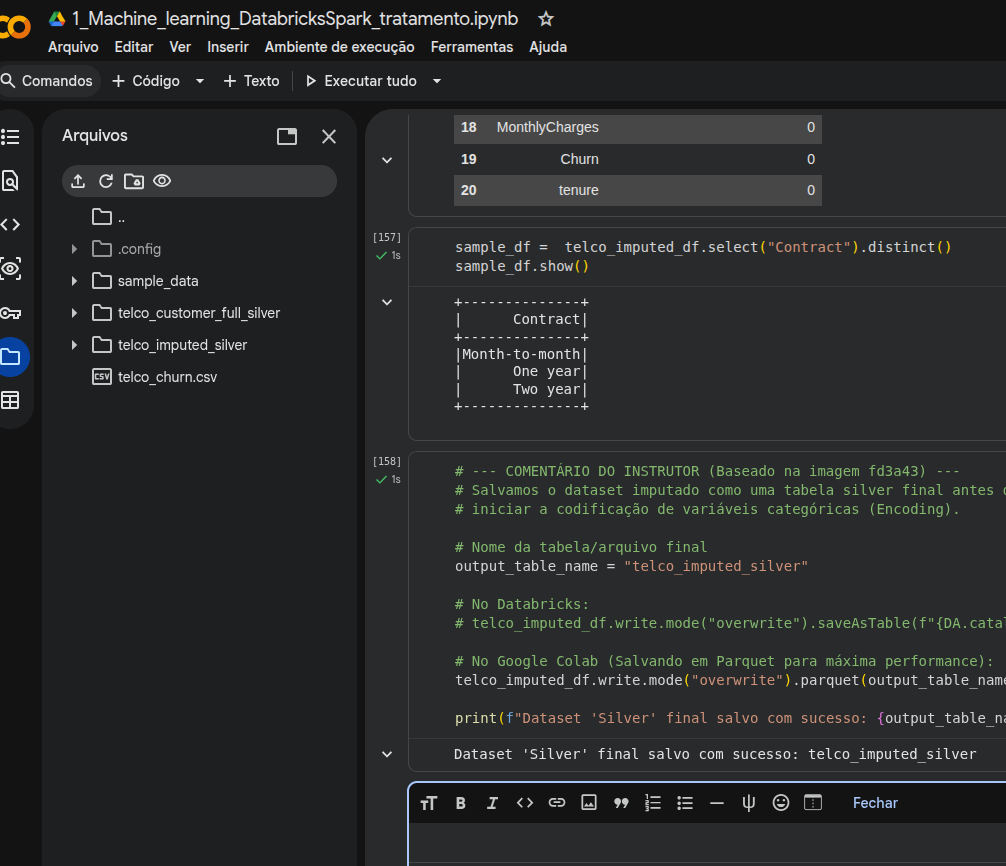

In [159]:
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import col

# 1. Definimos quais colunas categóricas queremos indexar
string_cols = ["Contract"]

# 2. Criamos os nomes das novas colunas de saída (ex: Contract_index)
index_cols = [column + "_index" for column in string_cols]

# 3. Configuramos o StringIndexer
# handleInvalid="keep" é fundamental: ele reserva um índice específico para valores nulos
string_indexer = StringIndexer(inputCols=string_cols, outputCols=index_cols, handleInvalid="keep")

# 4. Ajustamos o modelo aos dados (fit) e aplicamos a transformação (transform)
string_indexer_model = string_indexer.fit(sample_df)
indexed_df = string_indexer_model.transform(sample_df)

# Exibindo o resultado da conversão
indexed_df.show()


+--------------+--------------+
|      Contract|Contract_index|
+--------------+--------------+
|Month-to-month|           0.0|
|      One year|           1.0|
|      Two year|           2.0|
+--------------+--------------+



# . Codificação com OneHotEncoder
Após o StringIndexer, utilizamos o OneHotEncoder para transformar os índices numéricos em vetores binários. Isso evita que o modelo atribua uma ordem de importância arbitrária às categorias.

In [160]:
# --- Célula 39 ---
from pyspark.ml.feature import OneHotEncoder

# 1. Definimos os nomes das colunas de saída (ex: Contract_ohe)
ohe_cols = [column + "_ohe" for column in string_cols]

# 2. Configuramos o OneHotEncoder
# handleInvalid="keep" garante que a categoria de "nulos" criada no Indexer seja preservada
ohe = OneHotEncoder(inputCols=index_cols, outputCols=ohe_cols, handleInvalid="keep")

# 3. Ajustamos e transformamos o DataFrame
ohe_model = ohe.fit(indexed_df)
ohe_df = ohe_model.transform(indexed_df)

# Exibindo a representação vetorial (ex: (4, [1], [1.0]) indica o tamanho do vetor e a posição ativa)
#ohe_df.select("Contract", "Contract_index", "Contract_ohe").show()
ohe_df.show()

+--------------+--------------+-------------+
|      Contract|Contract_index| Contract_ohe|
+--------------+--------------+-------------+
|Month-to-month|           0.0|(4,[0],[1.0])|
|      One year|           1.0|(4,[1],[1.0])|
|      Two year|           2.0|(4,[2],[1.0])|
+--------------+--------------+-------------+



# 3. Vetorização e Indexação Ordenada
Para colunas que possuem uma ordem natural (como o tipo de contrato), o tratamento é diferente do One-Hot Encoding tradicional.

In [161]:
from pyspark.ml.feature import VectorAssembler

# --- PASSO C: Vector Assembler ---
# Consolidamos as variáveis preditoras (features) em uma única coluna de vetor.
selected_ohe_cols = ["Contract_ohe"]
assembler = VectorAssembler(inputCols=selected_ohe_cols, outputCol="features")

result_df_dense = assembler.transform(ohe_df)
result_df_dense.select("Contract", "features").show(truncate=False)

+--------------+-------------+
|Contract      |features     |
+--------------+-------------+
|Month-to-month|(4,[0],[1.0])|
|One year      |(4,[1],[1.0])|
|Two year      |(4,[2],[1.0])|
+--------------+-------------+



#  Ordered Indexing

In [162]:
# --- PASSO D: Ordered Indexing (Conceito) ---
# Algumas colunas categóricas são ORDINAIS (tem uma ordem natural que deve ser preservada).
# Exemplo: Month-to-month -> One year -> Two year.
# Mapear essas categorias manualmente para inteiros pode melhorar a performance do modelo.
ordinal_cat = "Contract"
telco_imputed_df.select(ordinal_cat).distinct().show()

+--------------+
|      Contract|
+--------------+
|Month-to-month|
|      One year|
|      Two year|
+--------------+



# 5. Codificação Ordinal Manual

Para colunas onde a ordem importa (como tempo de contrato).

In [163]:
# Define a ordem lógica das categorias
ordered_list = ["Month-to-month", "One year", "Two year"]
ordinal_dict = {category: f"{index + 1}" for index, category in enumerate(ordered_list)}
print(ordinal_dict)

{'Month-to-month': '1', 'One year': '2', 'Two year': '3'}


In [164]:
ordinal_cat

'Contract'

In [165]:

# Aplica o mapeamento manual
from pyspark.sql.functions import col
ordinal_df = (
    telco_imputed_df
    .withColumn("Contract_ord", col("Contract"))
    .replace(to_replace=ordinal_dict, subset=["Contract_ord"])
    .withColumn("Contract_ord", col("Contract_ord").cast('int'))
)

In [167]:
display(ordinal_df.select(ordinal_cat,f"{ordinal_cat}_ord"))

DataFrame[Contract: string, Contract_ord: int]

In [169]:
display(ordinal_df.select(ordinal_cat,f"{ordinal_cat}_ord").toPandas().sample(5))

,Contract,Contract_ord
2306,Month-to-month,1
5696,Month-to-month,1
3384,Month-to-month,1
270,Month-to-month,1
6535,One year,2


# 4. Divisão dos Dados (Splitting)

Esta é a última etapa antes do treinamento para evitar o Data Leakage (vazamento de dados).

In [170]:
# Divide em 80% para treino e 20% para teste com uma semente fixa para reprodutibilidade
train_df, test_df = telco_imputed_df.randomSplit([0.8, 0.2], seed=42)

# Salva ambos como tabelas Delta para garantir estabilidade no notebook
train_df.write.mode("overwrite").saveAsTable("telco_customers_train")
test_df.write.mode("overwrite").saveAsTable("telco_customers_baseline")

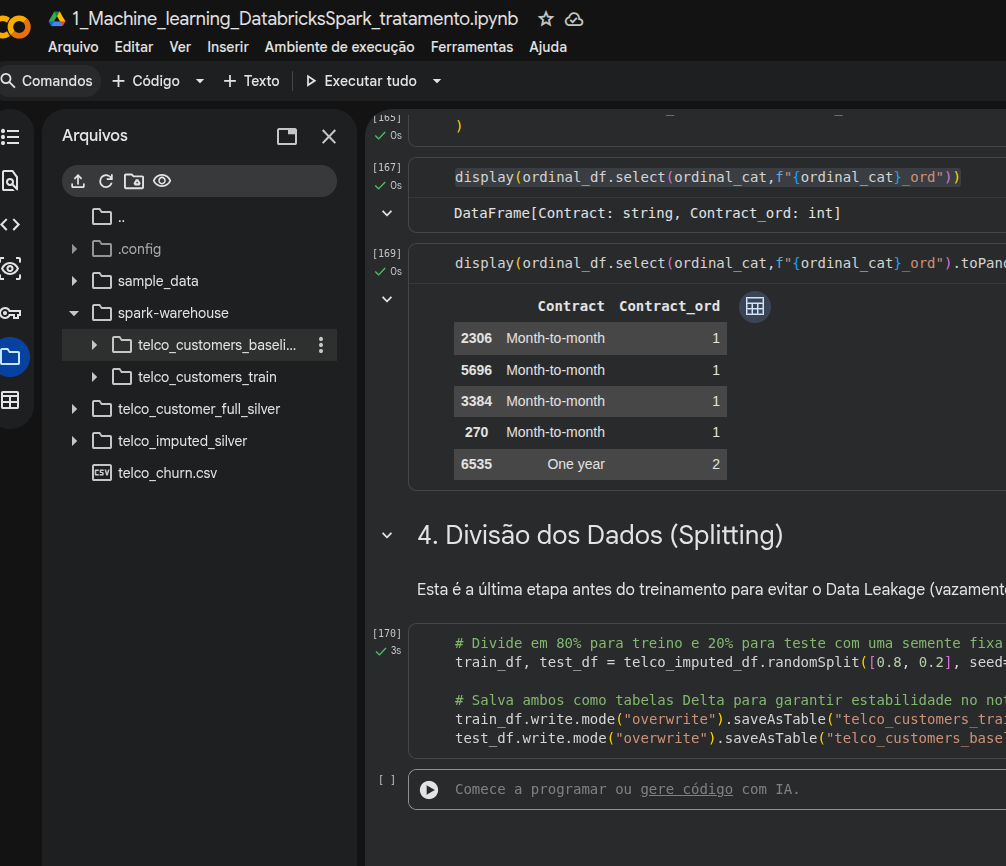

# standardizer features in a training set

5. Padronização de Atributos (Scaling)



In [172]:

from pyspark.ml.feature import RobustScaler, VectorAssembler

# 1. Definimos a coluna numérica que queremos escalar
num_cols_to_scale = ["MonthlyCharges"]

# 2. Agrupamos essa coluna em um vetor (exigência do Spark ML)
assembler = VectorAssembler().setInputCols(num_cols_to_scale).setOutputCol("numerical_assembled")

# Transformamos os conjuntos de treino e teste
train_assembled_df = assembler.transform(train_df.select(*num_cols_to_scale))
test_assembled_df = assembler.transform(test_df.select(*num_cols_to_scale))

# 3. Configuramos o RobustScaler
# Ele usa a amplitude interquartil (IQR), sendo mais resistente a outliers
scaler = RobustScaler(inputCol="numerical_assembled", outputCol="numerical_scaled")

# IMPORTANTE: O ajuste (fit) é feito APENAS no conjunto de treino
scaler_fitted = scaler.fit(train_assembled_df)

# Aplicamos a escala em ambos os conjuntos
train_scaled_df = scaler_fitted.transform(train_assembled_df)
test_scaled_df = scaler_fitted.transform(test_assembled_df)

In [174]:
print('Training set (scaled)')
train_scaled_df.show(5)

Training set (scaled)
+--------------+-------------------+--------------------+
|MonthlyCharges|numerical_assembled|    numerical_scaled|
+--------------+-------------------+--------------------+
|          65.6|             [65.6]|[1.2148148148148146]|
|          59.9|             [59.9]|[1.1092592592592592]|
|          98.0|             [98.0]|[1.8148148148148147]|
|          83.9|             [83.9]|[1.5537037037037038]|
|          69.4|             [69.4]|[1.2851851851851852]|
+--------------+-------------------+--------------------+
only showing top 5 rows


In [175]:
print('Test set (scaled)')
test_scaled_df.show(5)

Test set (scaled)
+--------------+-------------------+--------------------+
|MonthlyCharges|numerical_assembled|    numerical_scaled|
+--------------+-------------------+--------------------+
|          73.9|             [73.9]|[1.3685185185185185]|
|         109.7|            [109.7]| [2.031481481481481]|
|          48.2|             [48.2]|[0.8925925925925926]|
|         101.3|            [101.3]|[1.8759259259259258]|
|          25.1|             [25.1]|[0.4648148148148148]|
+--------------+-------------------+--------------------+
only showing top 5 rows


# 1. Imputação de Valores Numéricos

Quando colunas numéricas ainda possuem valores ausentes, precisamos preenchê-los com uma estatística representativa para não perder dados importantes.

fluxo completo de Imputação de Valores Numéricos e Divisão de Dados, que são as etapas finais antes do treinamento do modelo.

In [176]:
from pyspark.ml.feature import Imputer

# Define o imputer para a coluna 'tenure' usando a estratégia da mediana
tenure_imputer = Imputer(
    inputCols=["tenure"],
    outputCols=["tenure_imputed"],
    strategy="median"
)

# O ajuste (fit) é feito APENAS no conjunto de treino para evitar vazamento de dados
tenure_imputer_fitted = tenure_imputer.fit(train_df.select("tenure"))

# Aplica o preenchimento nos conjuntos de treino e teste
train_tenure_imputed_df = tenure_imputer_fitted.transform(train_df.select("tenure"))
test_tenure_imputed_df = tenure_imputer_fitted.transform(test_df.select("tenure"))



Média vs. Mediana: O script utiliza a mediana porque ela é mais robusta contra outliers (valores muito fora do padrão). A média é recomendada apenas para distribuições normais sem valores extremos.

Estratégia: Para a variável tenure (tempo de permanência do cliente), que pode ser distorcida por clientes muito antigos ou muito novos, a mediana oferece um valor central mais fiel à realidade.

In [177]:
train_df.show(5)

+----------+----------+-------+------------+----------------+------+-------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+--------------------+--------------+------------+-----+------+
|customerID|Dependents|Partner|PhoneService|PaperlessBilling|gender|SeniorCitizen|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|tenure|
+----------+----------+-------+------------+----------------+------+-------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+--------------------+--------------+------------+-----+------+
|0002-ORFBO|      true|   true|        true|            true|Female|        false|           No|            DSL|            No|         Yes|              No|        Yes|      

In [178]:
test_df.show(2)

+----------+----------+-------+------------+----------------+------+-------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+--------------------+--------------+------------+-----+------+
|customerID|Dependents|Partner|PhoneService|PaperlessBilling|gender|SeniorCitizen|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|tenure|
+----------+----------+-------+------------+----------------+------+-------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+--------------------+--------------+------------+-----+------+
|0004-TLHLJ|     false|  false|        true|            true|  Male|        false|           No|    Fiber optic|            No|          No|             Yes|         No|      

In [179]:
print("Training set - tenure imputed:")
train_tenure_imputed_df.show(5)

print("Test set - tenure imputed:")
test_tenure_imputed_df.show(5))

SyntaxError: unmatched ')' (2020883859.py, line 5)